https://arxiv.org/abs/2504.10408

Paper: https://arxiv.org/pdf/2504.10408v1



# Summary
* The Ashbaugh–Hatch potential uses λ, σ, and the distance between beads to calculate the non-ionic interaction energy/forces between residues, both:
within the same CAHS chain, and
between different CAHS chains.
* λ (lambda) is a residue-specific parameter that was optimised/learned using experimental data. It is related to hydrophobicity/stickiness, but λ itself isn't a GRAVY or hydropathy score.
* AH and DH potentials both exclude directly bonded neighbors — that's what "360 exclusions" in the log output meant: 18 bonds/chain × 20 chains = 360.
Bonded neighbors interact only via the harmonic bond, not also via AH/DH, or the potential would double-count and distort the chain.
* The Debye–Hückel potential calculates the electrostatic interactions between charged beads, again both within and between chains, taking solution conditions such as ionic strength into account.
The harmonic bond potential keeps neighbouring residues connected and penalises them for deviating too far from their preferred bond distance.


Then, all of these potentials together define the forces acting on the beads (i.e.residues are mapped onto single beads).

Since IDPs have various conformations that make it hard to pinpoint long range interactions sometimes it can have this conformation but sometimes it can have the other conformation so these calculations are repeated a lot of times to get an emergent behavior of how they'll eventually interact.

In a nutshell, the simulation generates the microscopic behaviour, using the AH potential, DH potential, harmonic bonds, etc. OpenMM repeatedly integrates those forces to produce a trajectory of positions/conformations over time.
Then, the analysis takes that trajectory and calculates higher-level statistical properties that emerge from all those microscopic interactions.


In [ ]:
!git clone https://github.com/KULL-Centre/CALVADOS.git
!pip install ./CALVADOS

Cloning into 'CALVADOS'...
remote: Enumerating objects: 1516, done.
remote: Counting objects: 100% (562/562), done.
remote: Compressing objects: 100% (267/267), done.
remote: Total 1516 (delta 410), reused 357 (delta 294), pack-reused 954 (from 2)
Receiving objects: 100% (1516/1516), 1.27 MiB | 20.29 MiB/s, done.
Resolving deltas: 100% (925/925), done.
Processing ./CALVADOS
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 41.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


In [ ]:
!pip install MDAnalysis networkx pandas matplotlib pymbar

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.9/108.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.1 MB/s eta 0:00:00


In [ ]:
import os
from calvados.cfg import Config, Components
import random

In [ ]:
wt_seq = "TEAYRKQQEVEADKIRKELEKQHLRDVEFRKDIVEMAIENQKKMIDVESRYAKKDMDRERVKV" # original PrCAHS1

CAHS_deltacore_seq = "MSAEAMNMNMNQDAVFIPPPEGEQYERKEKQEIQQTSYLQSQVKVPLVNLPAPFFSTSFSAQEILGEGFQASISRISAVSEELSSIEIPELAEEARRDFAAKTREQEMLSANYQKEVERKRMMLEQQKFHSDIQVNLDSSAAGTETGGQVVSESQKFTERNRQIKQ"

# negative_ctrl = ''.join(random.sample(wt_seq, len(wt_seq))) # randomly shuffling wt_seq
SEQUENCES = {
    "WT_motif1":     wt_seq,
    "CAHS_deltacore": CAHS_deltacore_seq,
    "negative_ctrl": "KLIVAQKDVEQTKELEKQVRSEEIMDKYADMEKNERDQEKADYVHRERRKRDEFKKVAVIRIM",
    "candidate_01":  "TEAIRRQMRRAKGRIRKEMTKMHLRDVEFRKDIVEMAIENQKKMIDVESRYAKKDMDRERVKV",
    "worst_performing": "TEARRKRMGKEKGRVRKELAKMHLRDVEFRKDIVEMAIENQKKMIDVESRYAKKDMDRERVKV",
    "CAHS_Full": "MSAEAMNMNMNQDAVFIPPPEGEQYERKEKQEIQQTSYLQSQVKVPLVNLPAPFFSTSFSAQEILGEGFQASISRISAVSEELSSIEIPELAEEARRDFAAKTREQEMLSANYQKEVERKTEAYRKQQEVEADKIRKELEKQHLRDVEFRKDIVEMAIENQKKMIDVESRYAKKDMDRERVKVRMMLEQQKFHSDIQVNLDSSAAGTETGGQVVSESQKFTERNRQIKQ"}

# print(len(wt_seq), len((SEQUENCES["worst_performing"])))

In [ ]:
import os
import random
# Path to the bundled residue parameter file (amino acid,MolecularWeight,lambdas,sigmas,q,bondlength) -> reused the one shipped with CALVADOS repo
RESIDUES_CSV = os.path.abspath("residues_CALVADOS2.csv")

# SEQUENCES
#    ↓
# create idr.fasta
#    ↓
# create config.yaml
#    ↓
# create components.yaml
#    ↓
# 02_run_all.sh / run.py
#    ↓
# CALVADOS simulation actually runs
#    ↓
# trajectory / output files

# condition label -> (box edge nm, systems to run)

COND, BOX = "2mM", 25.5
TEMP_K, IONIC_M = 293, 0.09
N_SAVE       = 1000     # integration steps between saved frames

# was originally 2000
N_FRAMES     = 5000     # frames to save -> raise this if clusters haven't stabilised by the end of the trajectory (check in step 3)
PLATFORM     = "CUDA"   # "CUDA" on a Colab GPU runtime, "CPU" otherwise
N_CHAINS = 20
cwd = os.getcwd()
BOX_OF = {}

for name, seq in SEQUENCES.items():
    label = f"{name}_{COND}"
    sysdir = os.path.join(cwd, label)
    os.makedirs(sysdir, exist_ok=True)
    BOX_OF[label] = BOX

    fasta_path = os.path.join(sysdir, "idr.fasta")
    with open(fasta_path, "w") as f:
        f.write(f">{name}\n{seq}\n")

    config = Config(
        sysname=label,
        box=[BOX, BOX, BOX],
        temp=TEMP_K,
        ionic=IONIC_M,
        pH=7.0,
        topol="grid",
        wfreq=N_SAVE,
        steps=N_FRAMES * N_SAVE,
        platform=PLATFORM,
        restart="checkpoint",
        frestart="restart.chk",
        random_number_seed=42,
        verbose=True,
    )
    config.write(sysdir, name="config.yaml")

    components = Components(
        molecule_type="protein",
        nmol=1,
        restraint=False,
        ext_restraint=False,
        charge_termini="both",
        fresidues=RESIDUES_CSV,
        ffasta=fasta_path,
    )
    components.add(name=name, nmol=N_CHAINS, ext_restraint=False)
    components.write(sysdir, name="components.yaml")
    print(f"[ok] prepared {label}")

[ok] prepared WT_motif1_2mM
[ok] prepared CAHS_deltacore_2mM
[ok] prepared negative_ctrl_2mM
[ok] prepared candidate_01_2mM
[ok] prepared worst_performing_2mM
[ok] prepared CAHS_Full_2mM


In [ ]:
import calvados, os, subprocess
d = os.path.dirname(calvados.__file__)
print(subprocess.run(["grep", "-rn", "-i", "seed", d], capture_output=True, text=True).stdout or "no 'seed' found")

/usr/local/lib/python3.13/site-packages/calvados/inputmodels.py:170:    random_number_seed: int | None = None
/usr/local/lib/python3.13/site-packages/calvados/sim.py:663:        if self.config.random_number_seed is not None:
/usr/local/lib/python3.13/site-packages/calvados/sim.py:664:            integrator.setRandomNumberSeed(self.config.random_number_seed)
/usr/local/lib/python3.13/site-packages/calvados/sim.py:743:            if self.config.random_number_seed is not None:
/usr/local/lib/python3.13/site-packages/calvados/sim.py:744:                integrator.setRandomNumberSeed(self.config.random_number_seed)
/usr/local/lib/python3.13/site-packages/calvados/sim.py:802:            if self.config.random_number_seed is not None:
/usr/local/lib/python3.13/site-packages/calvados/sim.py:803:                integrator.setRandomNumberSeed(self.config.random_number_seed)



In [ ]:
!MPLBACKEND=Agg bash 02_run_all.sh

Running: CAHS_deltacore_2mM
Adding charges for both termini of CAHS_deltacore.
Total number of components in the system: 1
Total number of molecules in the system: 20
Ashbaugh-Hatch potential between particles with lambda=1 and sigma=0.68 at 2.0 nm: -0.0051627815139227455 kJ/mol
Debye-Hückel potential between unit charges at 4.0 nm: 0.008460874920928478 kJ/mol
Component 0, Molecule 0: CAHS_deltacore
Component 0, Molecule 1: CAHS_deltacore
Component 0, Molecule 2: CAHS_deltacore
Component 0, Molecule 3: CAHS_deltacore
Component 0, Molecule 4: CAHS_deltacore
Component 0, Molecule 5: CAHS_deltacore
Component 0, Molecule 6: CAHS_deltacore
Component 0, Molecule 7: CAHS_deltacore
Component 0, Molecule 8: CAHS_deltacore
Component 0, Molecule 9: CAHS_deltacore
Component 0, Molecule 10: CAHS_deltacore
Component 0, Molecule 11: CAHS_deltacore
Component 0, Molecule 12: CAHS_deltacore
Component 0, Molecule 13: CAHS_deltacore
Component 0, Molecule 14: CAHS_deltacore
Component 0, Molecule 15: CAHS_d

In [ ]:
from google.colab import drive

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

!cp -r /content/CAHS_deltacore_2mM /content/drive/MyDrive/
!cp -r /content/WT_motif1_2mM /content/drive/MyDrive/
!cp -r /content/candidate_01_2mM /content/drive/MyDrive/
!cp -r /content/negative_ctrl_2mM /content/drive/MyDrive/
!cp -r /content/worst_performing_2mM /content/drive/MyDrive/
!cp -r /content/CAHS_Full_2mM /content/drive/MyDrive/

Mounted at /content/drive


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


done WT_motif1_2mM
done CAHS_deltacore_2mM
done negative_ctrl_2mM
done candidate_01_2mM
done worst_performing_2mM
done CAHS_Full_2mM
                              sequence cond  conc_mM  box_nm  res_per_chain  frames  t0_Rg  t0_contacts  Neff_Rg  Neff_contacts  Rg_nm  Rg_sem  contacts  contacts_sem  frac_mp1  frac_mp1_sem  frac_mp5  frac_mp5_sem  frac_mp10  frac_mp10_sem
label                                                                                                                                                                                                                                           
candidate_01_2mM          candidate_01  2mM        2    25.5             63    5000     15            2      453            310  2.296   0.010     0.616         0.050     0.108         0.002     0.066         0.002      0.053          0.000
negative_ctrl_2mM        negative_ctrl  2mM        2    25.5             63    5000      7            7      457            241  2.301   0.005  

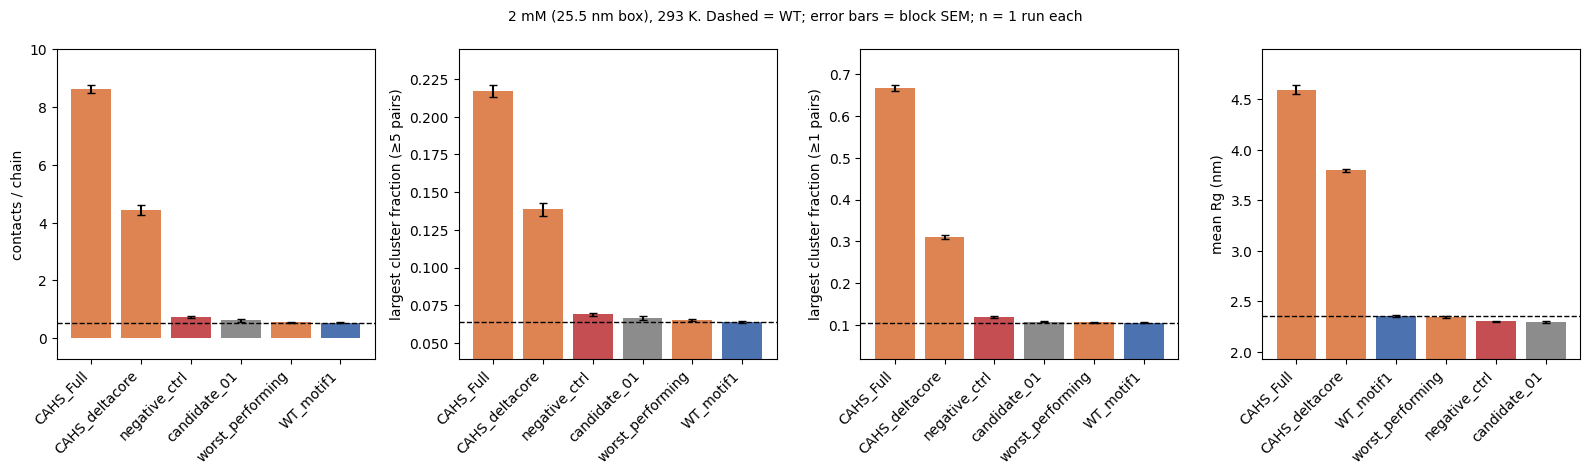

In [ ]:
import numpy as np, pandas as pd, mdtraj as md
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from pymbar import timeseries

# ---------- settings ----------
CUT          = 0.7              # nm, contact cutoff

# testing two definitions: more than or equal to 5 bead-bead contacts; more than or equal to 10 bead-bead contacts
MIN_PAIRS_LS = [1, 5, 10]          # min bead-bead pairs for two chains to count as connected

# throwing away 30% of frames b4 final averages/SEM
DISCARD      = 0.3              # same discard fraction for every system

# used to calculate the block SEM. Frame traj arent independent
# block averaging gives a better estimate of uncertainty
N_BLOCKS     = 5

# condition key -> (box edge nm, conc mM, Drive folder, label suffix used when the runs were prepared)
COND_INFO = {
    "2mM": (25.5, 2, "2mM", "2mM")
    # "c20mM":  (12, 20,  "20mM",  "20mM"),
}
# which systems were run at which condition (names must be keys of SEQUENCES)
RUN_SEQS = {
    "2mM": list(SEQUENCES)
    # "c20mM":  list(SEQUENCES),
}

RUNS = {}                           # label -> (sequence name, condition key)
for cond, names in RUN_SEQS.items():
    suffix = COND_INFO[cond][3]
    for n in names:
        RUNS[f"{n}_{suffix}"] = (n, cond)

def get_paths(label, cond):
    folder = COND_INFO[cond][2]
    return (f"drive/MyDrive/{folder}/{label}/{label}.dcd",
            f"drive/MyDrive/{folder}/{label}/top.pdb")

# ---------- helpers ----------
# because sim uses periodic boundary conditions
# A chain can cross the boundary
def unwrap_chain(c, L):                     # c: (frames, n_res, 3)
    d = np.diff(c, axis=1) # calculates distance between consecutive residues
    d -= L * np.round(d / L) # applies min-image condition
    return np.concatenate([c[:, :1], c[:, :1] + np.cumsum(d, axis=1)], axis=1) # reconstruct the chain

# calculating mean and SEM
def block_stats(x, n=N_BLOCKS):
    # split blocks into a block of 700 frames if analysing 3500 frames in total
    # and each block gets 1 mean
    b = np.array([blk.mean() for blk in np.array_split(x, n)])

    # SEM = S_blocks / sqrt(5)
    # so reported SEM represents uncertainty in the estimated trajectory mean based on the variability between blocks
    return b.mean(), b.std(ddof=1) / np.sqrt(len(b))

# detecting equilibration
# used for things like Rg vs frame, contacts vs frame
def safe_equil(x):
    # max(x) - min(x)

    if np.ptp(x) == 0:                      # flat series can make pymbar fail
        return 0, np.nan, np.nan
    try:
      # t0 = estimated equilibration starting frame
      # g = statistical inefficiency / autocorrelation-related factor
      # neff = estimated effective number of independent samples
      # for e.g. if t0=800; g = 20; Neff = 210
      # the first ~800 frames are estimated to be non-equilibrated, and because the trajectory is correlated
      # 5000 raw frames correspond to only ~210 effectively independent observations after accounting for autocorrelation
        t0, g, neff = timeseries.detect_equilibration(x)
        return t0, g, round(neff)
    except Exception:
        return np.nan, np.nan, np.nan

def analyse(label):
    name, cond = RUNS[label] # sequence name, condition
    L, conc, _, _ = COND_INFO[cond] # box size, concentration
    dcd, top = get_paths(label, cond) # dcd path, pdb path
    traj = md.load(dcd, top=top) # reads the trajectory
    xyz = traj.xyz.astype(np.float64)       # give coordinates with shape (frames, beads, 3), nm
    nf = xyz.shape[0] # gets the number of frames

    # chain length comes from the trajectory, so any sequence length works
    assert traj.n_atoms % N_CHAINS == 0, f"{label}: {traj.n_atoms} beads not divisible by {N_CHAINS}"
    n_res = traj.n_atoms // N_CHAINS
    chain_id = np.repeat(np.arange(N_CHAINS), n_res)
    if name in SEQUENCES and len(SEQUENCES[name]) != n_res:
        print(f"  note {label}: {n_res} beads/chain vs sequence length {len(SEQUENCES[name])}")

    # Rg per chain, averaged over chains
    rg = np.zeros((nf, N_CHAINS)) # creates an empty array
    # rows = frames
    # columns = chains
    # loop through every chain
    for i in range(N_CHAINS):
      # extract its 63 or 166 residues and unwraps them across periodic boundaries
      # e.g. i = 0 -> chain 0 would be residues 0:62
        c = unwrap_chain(xyz[:, i*n_res:(i+1)*n_res], L)


      # calculates the radius of gyration
      # basically how spatially extended the chain is around its centre
        rg[:, i] = np.sqrt(((c - c.mean(1, keepdims=True))**2).sum(-1).mean(1))
    rg_mean = rg.mean(1) # averages rg across all chains in each frame, in results table
    if rg_mean.mean() > L / 4:
        print(f"  WARNING {label}: Rg {rg_mean.mean():.2f} nm is large for a {L} nm box")

    # contacts and cluster fractions, per frame
    contacts = np.zeros(nf)

    frac = {mp: np.full(nf, 1.0 / N_CHAINS) for mp in MIN_PAIRS_LS}   # default: all monomers
    for f in range(nf): # analysing the simulation frame by frame
        p = xyz[f] % L # apply periodic wrapping # ensures coordinates are inside [0, L)
        p[p >= L] = 0.0 # handles any numerical edge cases at exactly the boundary

        # instead of comparing every bead with every other bead, cKDTree efficiently finds pairs within 0.7nm whil respecting periodic box

        pairs = cKDTree(p, boxsize=L).query_pairs(CUT, output_type="ndarray")

        # if no contacts, no bead-bead contacts at all, code therefore assumes every chain is a separate monomer
        if len(pairs) == 0:
            continue
        # determining which contacts are inter-chain, then converts bead IDs to chain IDs
        ci, cj = chain_id[pairs[:, 0]], chain_id[pairs[:, 1]]

        # INTERMOLECULAR interactions
        m = ci != cj # keeps only contacts where the two beads belong to different chains
        if not m.any():
            continue
        # caclulates the total num of residues that are in contact between chains
        # contacts / chain -> 2 * N_interchain contacts / N_chains
        contacts[f] = 2 * m.sum() / N_CHAINS

        # count contacts between each pair of chains
        # this ensures chain 1 <-> chain 3 and chain 3 <-> chain 1 are treated as the same pair
        a, b = np.minimum(ci[m], cj[m]), np.maximum(ci[m], cj[m])

        # creates a matrix
        cnt = np.zeros((N_CHAINS, N_CHAINS), int)

        # counts how many bead-bead contacts occur between each chain pair
        np.add.at(cnt, (a, b), 1)
        for mp in MIN_PAIRS_LS: # mp = 5; mp=10; mp = 1

            # turns the contact-count matrix into a graph
            # for mp = 5, a pair of chains is connected if number of bead contacts >= 5


            n_comp, lab = connected_components(cnt >= mp, directed=False)
            # sizes = np.bincount(lab)
            # nclust[mp][f] = n_comp
            # frac_nonmono[mp][f] = (sizes > 1).dot(sizes) / N_CHAINS
            # wavg[mp][f] = (sizes**2).sum() / sizes.sum()
            # # finds the largest cluster
            frac[mp][f] = np.bincount(lab).max() / N_CHAINS # largest cluster fraction

    # detect equlibration
    # independently analyse Rg time series, contacts time series
    # and estimate t0_Rg, Neff_Rg; t0_contacts, Neff_contacts
    t0_rg, _, neff_rg = safe_equil(rg_mean)
    t0_ct, _, neff_ct = safe_equil(contacts)

    s = int(DISCARD * nf)
    row = {"label": label, "sequence": name, "cond": cond, "conc_mM": conc, "box_nm": L,
           "res_per_chain": n_res, "frames": nf, "t0_Rg": t0_rg, "t0_contacts": t0_ct,
           "Neff_Rg": neff_rg, "Neff_contacts": neff_ct}
    row["Rg_nm"], row["Rg_sem"] = block_stats(rg_mean[s:])
    row["contacts"], row["contacts_sem"] = block_stats(contacts[s:])
    for mp in MIN_PAIRS_LS:
        row[f"frac_mp{mp}"], row[f"frac_mp{mp}_sem"] = block_stats(frac[mp][s:])
    return row, dict(rg=rg_mean, contacts=contacts, frac=frac)

# ---------- run all systems ----------
rows, series = [], {}
for label in RUNS:
    try:
        row, ser = analyse(label)
    except Exception as e:
        print("skipped", label, "->", type(e).__name__, e)
        continue
    rows.append(row); series[label] = ser
    print("done", label)

results = pd.DataFrame(rows).set_index("label").sort_values(["conc_mM", "Rg_nm"])
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40)
print(results.round(3))
results.to_csv("sim_results_all_conditions.csv")

# ---------- sorted bar charts, one figure per condition ----------
def colour(s):
    if s == "WT_motif1": return "#4C72B0"
    if s.startswith(("negative_ctrl", "shuffle")): return "#C44E52"
    if s.startswith("candidate"): return "#8C8C8C"
    return "#DD8452"                         # other controls (e.g. deltaCore / Full)

panels = [("contacts / chain", "contacts", "contacts_sem"),
          ("largest cluster fraction (≥5 pairs)", "frac_mp5", "frac_mp5_sem"),
          ("largest cluster fraction (≥1 pairs)", "frac_mp1", "frac_mp1_sem"),
          ("mean Rg (nm)", "Rg_nm", "Rg_sem")]
DESCENDING = True

for cond in results["cond"].unique():
    r = results[results["cond"] == cond].set_index("sequence")
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.8))
    for ax, (title, col, err) in zip(axes, panels):
        d = r.sort_values(col, ascending=not DESCENDING)
        ax.bar(range(len(d)), d[col], yerr=d[err], capsize=3, color=[colour(s) for s in d.index])
        if "WT_motif1" in r.index:
            ax.axhline(r.loc["WT_motif1", col], ls="--", lw=1, color="k")
        ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=45, ha="right")
        ax.set_ylabel(title)
        lo, hi = (d[col] - d[err]).min(), (d[col] + d[err]).max()
        pad = (hi - lo) * 0.15 or 0.01
        ax.set_ylim(lo - pad, hi + pad)
    fig.suptitle(f"{r['conc_mM'].iloc[0]} mM ({r['box_nm'].iloc[0]} nm box), 293 K. "
                 "Dashed = WT; error bars = block SEM; n = 1 run each", fontsize=10)
    plt.tight_layout(); fig.savefig(f"bars_{cond}.png", dpi=200); plt.show()



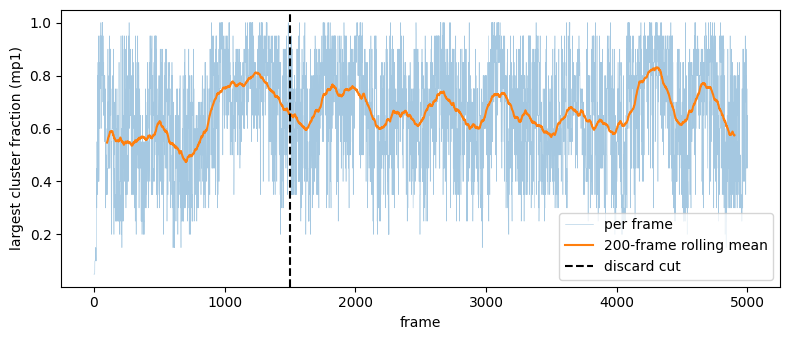

In [ ]:
# shows that CAHS Full has converged and is mostly oscillating within a small range
# bcz t0 of 1280 is close to the discarded amount (1500), with the shorter sequences being
# in the hundreds
label = "CAHS_Full_2mM"
y = series[label]["frac"][1]          # per-frame largest-cluster fraction, mp1
x = np.arange(len(y))
roll = pd.Series(y).rolling(200, center=True).mean()   # smooths frame-to-frame noise

plt.figure(figsize=(8, 3.5))
plt.plot(x, y, lw=0.4, alpha=0.4, label="per frame")
plt.plot(x, roll, lw=1.5, label="200-frame rolling mean")
plt.axvline(int(DISCARD * len(y)), ls="--", c="k", label="discard cut")
plt.xlabel("frame"); plt.ylabel("largest cluster fraction (mp1)")
plt.legend(); plt.tight_layout(); plt.show()

done WT_motif1_2mM
done CAHS_deltacore_2mM
done negative_ctrl_2mM
done candidate_01_2mM
done worst_performing_2mM
done CAHS_Full_2mM
                              sequence cond  conc_mM  box_nm  res_per_chain  frames  t0_Rg  t0_contacts  Neff_Rg  Neff_contacts  Rg_nm  Rg_sem  contacts  contacts_sem  frac_mp1  frac_mp1_sem  nonmono_mp1  nonmono_mp1_sem  wavg_mp1  wavg_mp1_sem  \
label                                                                                                                                                                                                                                                  
candidate_01_2mM          candidate_01  2mM        2    25.5             63    5000     15            2      453            310  2.296   0.010     0.616         0.050     0.108         0.002        0.192            0.012     1.242         0.016   
negative_ctrl_2mM        negative_ctrl  2mM        2    25.5             63    5000      7            7      457           

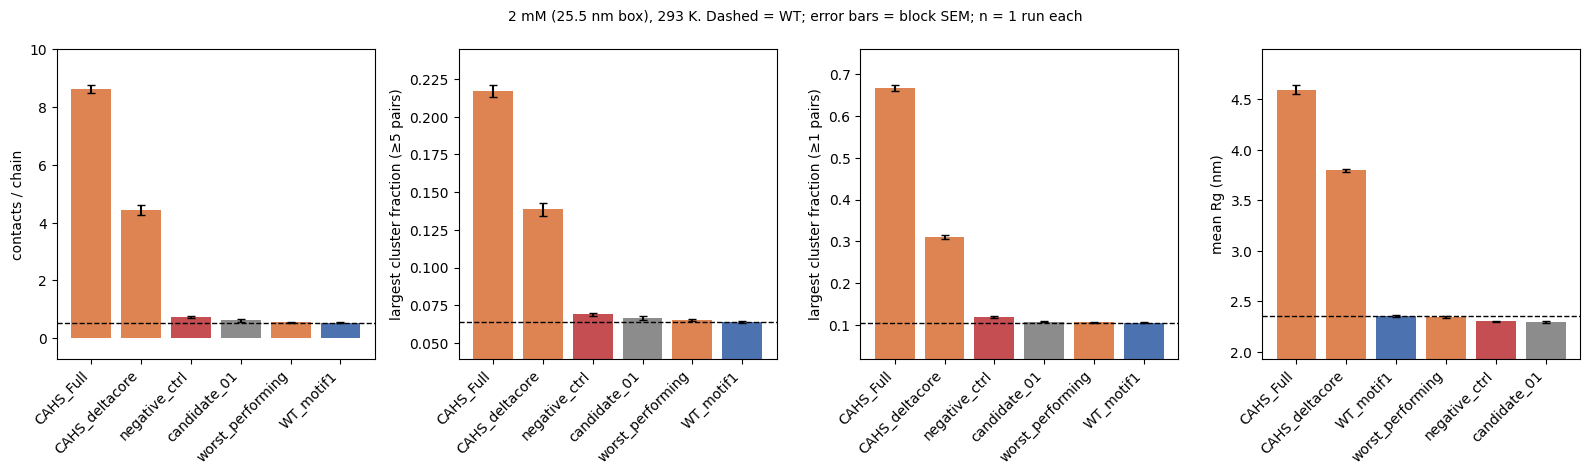

In [ ]:
"""
nclust: full means 1, 20 means every chain is alone
e.g. Candidate_01 at mp1 has 17.9, so on average about
2 "links" have joined chains together (20 - 17.9 ≈ 2.1).
Full has 5.0, so its 20 chains are merged into about 5 groups on average.
Basically number of clusters

non_mono: the fraction of chains that sit in a cluster of size ≥ 2
num_chains that are actually part of the cluster.

wavg: weight-average cluster size, Σs² / Σs. If you pick a chain at random,
larger clusters are disproportionately likely to be the cluster you find it in,
and the resulting chain-weighted average cluster size is 10.
So Full at mp1 (10.6) means a random chain sits in a cluster of about 10.6 chains.
Monomers pull it towards 1

frac: largest cluster size / 20

"""

import numpy as np, pandas as pd, mdtraj as md
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.sparse.csgraph import connected_components
from pymbar import timeseries

# ---------- settings ----------
CUT          = 0.7              # nm, contact cutoff

# testing two definitions: more than or equal to 5 bead-bead contacts; more than or equal to 10 bead-bead contacts
MIN_PAIRS_LS = [1, 5, 10]          # min bead-bead pairs for two chains to count as connected

# throwing away 30% of frames b4 final averages/SEM
DISCARD      = 0.3              # same discard fraction for every system

# used to calculate the block SEM. Frame traj arent independent
# block averaging gives a better estimate of uncertainty
N_BLOCKS     = 5

# condition key -> (box edge nm, conc mM, Drive folder, label suffix used when the runs were prepared)
COND_INFO = {
    "2mM": (25.5, 2, "2mM", "2mM")
    # "c20mM":  (12, 20,  "20mM",  "20mM"),
}
# which systems were run at which condition (names must be keys of SEQUENCES)
RUN_SEQS = {
    "2mM": list(SEQUENCES)
    # "c20mM":  list(SEQUENCES),
}

RUNS = {}                           # label -> (sequence name, condition key)
for cond, names in RUN_SEQS.items():
    suffix = COND_INFO[cond][3]
    for n in names:
        RUNS[f"{n}_{suffix}"] = (n, cond)

def get_paths(label, cond):
    folder = COND_INFO[cond][2]
    return (f"drive/MyDrive/{folder}/{label}/{label}.dcd",
            f"drive/MyDrive/{folder}/{label}/top.pdb")

# ---------- helpers ----------
# because sim uses periodic boundary conditions
# A chain can cross the boundary
def unwrap_chain(c, L):                     # c: (frames, n_res, 3)
    d = np.diff(c, axis=1) # calculates distance between consecutive residues
    d -= L * np.round(d / L) # applies min-image condition
    return np.concatenate([c[:, :1], c[:, :1] + np.cumsum(d, axis=1)], axis=1) # reconstruct the chain

# calculating mean and SEM
def block_stats(x, n=N_BLOCKS):
    # split blocks into a block of 700 frames if analysing 3500 frames in total
    # and each block gets 1 mean
    b = np.array([blk.mean() for blk in np.array_split(x, n)])

    # SEM = S_blocks / sqrt(5)
    # so reported SEM represents uncertainty in the estimated trajectory mean based on the variability between blocks
    return b.mean(), b.std(ddof=1) / np.sqrt(len(b))

# detecting equilibration
# used for things like Rg vs frame, contacts vs frame
def safe_equil(x):
    # max(x) - min(x)

    if np.ptp(x) == 0:                      # flat series can make pymbar fail
        return 0, np.nan, np.nan
    try:
      # t0 = estimated equilibration starting frame
      # g = statistical inefficiency / autocorrelation-related factor
      # neff = estimated effective number of independent samples
      # for e.g. if t0=800; g = 20; Neff = 210
      # the first ~800 frames are estimated to be non-equilibrated, and because the trajectory is correlated
      # 5000 raw frames correspond to only ~210 effectively independent observations after accounting for autocorrelation
        t0, g, neff = timeseries.detect_equilibration(x)
        return t0, g, round(neff)
    except Exception:
        return np.nan, np.nan, np.nan

def analyse(label):
    name, cond = RUNS[label] # sequence name, condition
    L, conc, _, _ = COND_INFO[cond] # box size, concentration
    dcd, top = get_paths(label, cond) # dcd path, pdb path
    traj = md.load(dcd, top=top) # reads the trajectory
    xyz = traj.xyz.astype(np.float64)       # give coordinates with shape (frames, beads, 3), nm
    nf = xyz.shape[0] # gets the number of frames

    # chain length comes from the trajectory, so any sequence length works
    assert traj.n_atoms % N_CHAINS == 0, f"{label}: {traj.n_atoms} beads not divisible by {N_CHAINS}"
    n_res = traj.n_atoms // N_CHAINS
    chain_id = np.repeat(np.arange(N_CHAINS), n_res)
    if name in SEQUENCES and len(SEQUENCES[name]) != n_res:
        print(f"  note {label}: {n_res} beads/chain vs sequence length {len(SEQUENCES[name])}")

    # Rg per chain, averaged over chains
    rg = np.zeros((nf, N_CHAINS)) # creates an empty array
    # rows = frames
    # columns = chains
    # loop through every chain
    for i in range(N_CHAINS):
      # extract its 63 or 166 residues and unwraps them across periodic boundaries
      # e.g. i = 0 -> chain 0 would be residues 0:62
        c = unwrap_chain(xyz[:, i*n_res:(i+1)*n_res], L)


      # calculates the radius of gyration
      # basically how spatially extended the chain is around its centre
        rg[:, i] = np.sqrt(((c - c.mean(1, keepdims=True))**2).sum(-1).mean(1))
    rg_mean = rg.mean(1) # averages rg across all chains in each frame, in results table
    if rg_mean.mean() > L / 4:
        print(f"  WARNING {label}: Rg {rg_mean.mean():.2f} nm is large for a {L} nm box")

    # contacts and cluster fractions, per frame
    contacts = np.zeros(nf)

    frac = {mp: np.full(nf, 1.0 / N_CHAINS) for mp in MIN_PAIRS_LS}   # default: all monomers
    # sensible defaults
    nclust       = {mp: np.full(nf, float(N_CHAINS)) for mp in MIN_PAIRS_LS}  # default: all monomers
    frac_nonmono = {mp: np.zeros(nf) for mp in MIN_PAIRS_LS}
    wavg         = {mp: np.ones(nf) for mp in MIN_PAIRS_LS}
    size_hist    = np.zeros((len(MIN_PAIRS_LS), nf, N_CHAINS + 1))            # clusters of each size, per frame
    size_hist[:, :, 1] = N_CHAINS                                             # default: 20 monomers
    for f in range(nf): # analysing the simulation frame by frame
        p = xyz[f] % L # apply periodic wrapping # ensures coordinates are inside [0, L)
        p[p >= L] = 0.0 # handles any numerical edge cases at exactly the boundary

        # instead of comparing every bead with every other bead, cKDTree efficiently finds pairs within 0.7nm whil respecting periodic box

        pairs = cKDTree(p, boxsize=L).query_pairs(CUT, output_type="ndarray")

        # if no contacts, no bead-bead contacts at all, code therefore assumes every chain is a separate monomer
        if len(pairs) == 0:
            continue
        # determining which contacts are inter-chain, then converts bead IDs to chain IDs
        ci, cj = chain_id[pairs[:, 0]], chain_id[pairs[:, 1]]

        # INTERMOLECULAR interactions
        m = ci != cj # keeps only contacts where the two beads belong to different chains
        if not m.any():
            continue
        # caclulates the total num of residues that are in contact between chains
        # contacts / chain -> 2 * N_interchain contacts / N_chains
        contacts[f] = 2 * m.sum() / N_CHAINS

        # count contacts between each pair of chains
        # this ensures chain 1 <-> chain 3 and chain 3 <-> chain 1 are treated as the same pair
        a, b = np.minimum(ci[m], cj[m]), np.maximum(ci[m], cj[m])

        # creates a matrix
        cnt = np.zeros((N_CHAINS, N_CHAINS), int)

        # counts how many bead-bead contacts occur between each chain pair
        np.add.at(cnt, (a, b), 1)
        for mp in MIN_PAIRS_LS: # mp = 5; mp=10; mp = 1

            # turns the contact-count matrix into a graph
            # for mp = 5, a pair of chains is connected if number of bead contacts >= 5


            n_comp, lab = connected_components(cnt >= mp, directed=False)
            sizes = np.bincount(lab)
            nclust[mp][f] = n_comp

            # finds the percentage of chains thats part of a cluster
            frac_nonmono[mp][f] = (sizes > 1).dot(sizes) / N_CHAINS

            # a giant cluster count disproportionately more
            # e.g. [2][2][2][2][2] is just 2; [10] is 10
            wavg[mp][f] = (sizes**2).sum() / sizes.sum()


            size_hist[MIN_PAIRS_LS.index(mp), f] = np.bincount(sizes, minlength=N_CHAINS + 1)
            # finds the largest cluster
            frac[mp][f] = sizes.max() / N_CHAINS # largest cluster fraction

    # detect equlibration
    # independently analyse Rg time series, contacts time series
    # and estimate t0_Rg, Neff_Rg; t0_contacts, Neff_contacts
    t0_rg, _, neff_rg = safe_equil(rg_mean)
    t0_ct, _, neff_ct = safe_equil(contacts)

    s = int(DISCARD * nf)
    row = {"label": label, "sequence": name, "cond": cond, "conc_mM": conc, "box_nm": L,
           "res_per_chain": n_res, "frames": nf, "t0_Rg": t0_rg, "t0_contacts": t0_ct,
           "Neff_Rg": neff_rg, "Neff_contacts": neff_ct}
    row["Rg_nm"], row["Rg_sem"] = block_stats(rg_mean[s:])
    row["contacts"], row["contacts_sem"] = block_stats(contacts[s:])
    for mp in MIN_PAIRS_LS:

        row[f"frac_mp{mp}"], row[f"frac_mp{mp}_sem"] = block_stats(frac[mp][s:])
        row[f"nonmono_mp{mp}"], row[f"nonmono_mp{mp}_sem"] = block_stats(frac_nonmono[mp][s:])
        row[f"wavg_mp{mp}"], row[f"wavg_mp{mp}_sem"] = block_stats(wavg[mp][s:])
        row[f"nclust_mp{mp}"], row[f"nclust_mp{mp}_sem"] = block_stats(nclust[mp][s:])
    return row, dict(rg=rg_mean, contacts=contacts, frac=frac, size_hist=size_hist[:, s:].mean(1))

# ---------- run all systems ----------
rows, series = [], {}
for label in RUNS:
    try:
        row, ser = analyse(label)
    except Exception as e:
        print("skipped", label, "->", type(e).__name__, e)
        continue
    rows.append(row); series[label] = ser
    print("done", label)

results = pd.DataFrame(rows).set_index("label").sort_values(["conc_mM", "Rg_nm"])
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 40)
print(results.round(3))
results.to_csv("sim_results_all_conditions.csv")

# ---------- sorted bar charts, one figure per condition ----------
def colour(s):
    if s == "WT_motif1": return "#4C72B0"
    if s.startswith(("negative_ctrl", "shuffle")): return "#C44E52"
    if s.startswith("candidate"): return "#8C8C8C"
    return "#DD8452"                         # other controls (e.g. deltaCore / Full)

panels = [("contacts / chain", "contacts", "contacts_sem"),
          ("largest cluster fraction (≥5 pairs)", "frac_mp5", "frac_mp5_sem"),
          ("largest cluster fraction (≥1 pairs)", "frac_mp1", "frac_mp1_sem"),

          ("mean Rg (nm)", "Rg_nm", "Rg_sem")]
DESCENDING = True

for cond in results["cond"].unique():
    r = results[results["cond"] == cond].set_index("sequence")
    fig, axes = plt.subplots(1, 4, figsize=(16, 4.8))
    for ax, (title, col, err) in zip(axes, panels):
        d = r.sort_values(col, ascending=not DESCENDING)
        ax.bar(range(len(d)), d[col], yerr=d[err], capsize=3, color=[colour(s) for s in d.index])
        if "WT_motif1" in r.index:
            ax.axhline(r.loc["WT_motif1", col], ls="--", lw=1, color="k")
        ax.set_xticks(range(len(d))); ax.set_xticklabels(d.index, rotation=45, ha="right")
        ax.set_ylabel(title)
        lo, hi = (d[col] - d[err]).min(), (d[col] + d[err]).max()
        pad = (hi - lo) * 0.15 or 0.01
        ax.set_ylim(lo - pad, hi + pad)
    fig.suptitle(f"{r['conc_mM'].iloc[0]} mM ({r['box_nm'].iloc[0]} nm box), 293 K. "
                 "Dashed = WT; error bars = block SEM; n = 1 run each", fontsize=10)
    plt.tight_layout(); fig.savefig(f"bars_{cond}.png", dpi=200); plt.show()

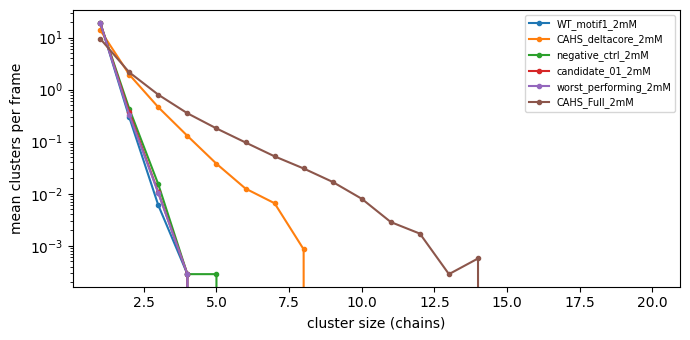

In [ ]:
mp_i = MIN_PAIRS_LS.index(5)          # choose the threshold: 1, 5 or 10
fig, ax = plt.subplots(figsize=(7, 3.5))
for lab_, ser in series.items():
    ax.plot(range(1, N_CHAINS + 1), ser["size_hist"][mp_i, 1:], marker="o", ms=3, label=lab_)
ax.set_yscale("log"); ax.set_xlabel("cluster size (chains)"); ax.set_ylabel("mean clusters per frame")
ax.legend(fontsize=7); plt.tight_layout(); plt.show()

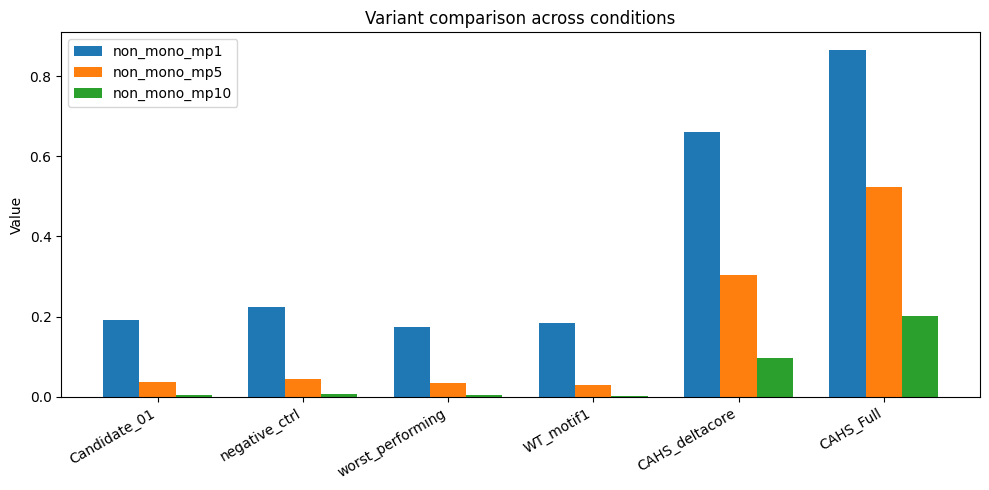

In [ ]:
import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt

variants = ["Candidate_01", "negative_ctrl", "worst_performing",
            "WT_motif1", "CAHS_deltacore", "CAHS_Full"]
data = {
    "non_mono_mp1":  [0.192, 0.225, 0.174, 0.184, 0.660, 0.866],
    "non_mono_mp5":   [0.038, 0.045, 0.034, 0.030, 0.305, 0.524],
    "non_mono_mp10": [0.005, 0.006, 0.004, 0.003, 0.096, 0.202],
}

LOG_SCALE = False  # set True: values span ~0.003 to ~0.87, so small bars are hard to see on a linear axis

x = np.arange(len(variants))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
for i, (label, vals) in enumerate(data.items()):
    ax.bar(x + (i - 1) * width, vals, width, label=label)

ax.set_xticks(x)
ax.set_xticklabels(variants, rotation=30, ha="right")
ax.set_ylabel("Value")
ax.set_title("Variant comparison across conditions")
if LOG_SCALE:
    ax.set_yscale("log")
ax.legend()
fig.tight_layout()
fig.savefig("variants_barchart.png", dpi=300)
plt.show()
